In [2]:
import pandas as pd
import numpy as np
import pyvista as pv
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from scipy.ndimage import zoom

from phd_helpers.paths import get_bone_inertia, get_subject_stl_path, transform_mesh
from phd_helpers.MeshQuality import check_mesh_quality, mesh_quality_summary, plot_bad_cells2

In [ ]:
HOW TO INTERP INTEGRATION_POINTS / ELEMENT_NODAL ?

In [43]:
def get_history_path(DIR, step=0):
    return DIR / (f"history_step-{step}.csv")

def get_field_path(DIR, metric, step, frame, instance):
    csvs = list(DIR.glob("*.csv"))
    return [x for x in csvs if f'{instance}-' in x.name and f'-{metric}-' in x.name and f'-{str(step)}-' in x.name and f'-{str(frame)}' in x.name][0]

def get_field_df(field_path):
    metric = field_path.name.split('-')[1]
    headers = []
    with open (field_path, 'r') as f:
        for line in f:
            headers = np.array(line.split(','))
            break

    df = pd.read_csv(field_path, skiprows=[0], header=None)
    cc_idx = np.where(np.array(headers)=='componentCount')[0] # idx of componentCount header
    cc = df.iloc[:1, cc_idx].values[0][0] # component count
    if cc == 1:
        df.columns = list(headers[:-1]) + [metric]
    else:
        df.columns = list(headers[:-1]) + [f'{metric}{x}' for x in range(1, cc+1)]

    df['nodeLabel'] -= 1 # Abaqus starts at 1
    return df

def add_field_to_mesh(mesh, field_df):
    cc = field_df.loc[:0, ['componentCount']].values[0][0] # component count

    # *************** NEED TO DECIDE ON INTERPOLATION METHOD IF NOT NODAL *************** #
    pos = field_df.loc[:0, ['position']].values[0][0] # NODAL, ELEMENT, ...
    # *************** NEED TO DECIDE ON INTERPOLATION METHOD IF NOT NODAL *************** #
    if pos != 'NODAL':
        raise RuntimeError("NEED TO DECIDE ON, AND IMPLEMENT, INTERPOLATION METHOD IF NOT NODAL")

    for x in range(1, cc+1):
        mesh[field_df.columns[-x]] = np.zeros(mesh.n_points)
        mesh[field_df.columns[-x]][field_df['nodeLabel']] = field_df.iloc[:, -x]

def get_deformed_mesh(mesh):
    mesh_def = mesh.copy(deep=True)
    mesh_def.points += np.column_stack((mesh['U1'], mesh['U2'], mesh['U3']))
    return mesh_def

def project_sensor(mesh, sensor: pv.Plane, sensor_vals, data_loc='cells', downscale_fea=True, return_fea_grid=False, downscale_mode='mean'):
    """Projects (planar) sensor values onto mesh and if downscale_fea: downscale mesh['CPRESS'] values onto sensor grid\n
    Assigns array of values to mesh['tek_press'] - point_data if data_loc='points' else cell_data\n
    Assigns downscaled fea values to mesh['fea_press']\n
    if return_fea_grid: return nci, ncj grid of downscaled fea values (if downscale_fea=True)"""

    # n sensor cells
    nci = sensor_vals.shape[0]
    ncj = sensor_vals.shape[1]

    # create orthonormal basis from sensor normal
    n = np.asarray(sensor.compute_normals()['Normals'][0])
    n = n / np.linalg.norm(n)

    a = np.array((0.0, 0.0, 1.0))
    if abs(np.dot(a, n)) > 0.99:
        a = np.array((0.0, 1.0, 0.0))

    u = np.cross(a, n); u /= np.linalg.norm(u)
    v = np.cross(n, u); v /= np.linalg.norm(v)

    # sensor bounds in u v coords
    P0 = np.asarray(sensor.center)
    pp = sensor.points - P0 # vector of each point from sensor centre (the points are the corners of each sensor cell)
    su = pp @ u             # vectors values in u direction
    sv = pp @ v             # vectors values in v direction
    u_min, u_max = su.min(), su.max() # outer bounds of sensor
    v_min, v_max = sv.min(), sv.max() # outer bounds of sensor

    du = (u_max - u_min) / ncj # size of each cell in u (column spacing - pitch)
    dv = (v_max - v_min) / nci # size of each cell in v (row spacing - pitch)

    # bin mesh cell centres in u v sensor cell bins
    centres = mesh.cell_centers().points
    if data_loc == 'points':
        centres = mesh.points

    cc = centres - P0 # vector of each cell centre from sensor centre
    cu = cc @ u # vectors values in u direction
    cv = cc @ v # vectors values in v direction

    iu = np.floor((cu - u_min) / du).astype(int) # j of sensor cell that the cell centre falls in (not bounded by sensor yet)
    iv = np.floor((cv - v_min) / dv).astype(int) # i of sensor cell that the cell centre falls in (not bounded by sensor yet)

    out = np.zeros(len(centres), dtype=float)
    inside = (iu >= 0) & (iu < ncj) & (iv >= 0) & (iv < nci) # mask of cell centres that are within bounds of sensor
    out[inside] = sensor_vals[iv[inside], iu[inside]]  # assign sensor values to mesh cells

    mesh['sensor_cell'] = list(zip(iv, iu))
    mesh["tek_press"] = out

    if downscale_fea:
        fea_vals = mesh.point_data_to_cell_data()['CPRESS']
        if data_loc == 'points':
            fea_vals = mesh['CPRESS']

        if downscale_mode == 'mean':
            # accumulate mean in sensor grid
            fea_sum = np.zeros((nci, ncj))
            fea_count = np.zeros((nci, ncj), dtype=int)
            np.add.at(fea_sum, (iv[inside], iu[inside]), fea_vals[inside])
            np.add.at(fea_count, (iv[inside], iu[inside]), 1)
            fea_grid = np.zeros((nci, ncj))
            np.divide(fea_sum, fea_count, out=fea_grid, where=fea_count > 0)
        elif downscale_mode == 'max':
            fea_grid = np.full((nci, ncj), -np.inf, dtype=float)
            fea_count = np.zeros((nci, ncj), dtype=int)
            np.maximum.at(fea_grid, (iv[inside], iu[inside]), fea_vals[inside])
            np.add.at(fea_count, (iv[inside], iu[inside]), 1)
            fea_grid[fea_count == 0] = 0.0

        # reproject onto mesh
        fea_ds = np.zeros(len(centres))
        valid = inside.copy()
        valid[inside] &= (fea_count[iv[inside], iu[inside]] > 0)
        fea_ds[valid] = fea_grid[iv[valid], iu[valid]]
        mesh["fea_press"] = fea_ds
        if return_fea_grid:
            return fea_grid


def extract_bone_cartilage(mesh):
    mesh_shell = mesh.extract_cells_by_type(5)
    cartilage_surf_mask = np.where(mesh_shell['region_id']==-2)[0]
    cartilage_surf = mesh_shell.extract_cells(cartilage_surf_mask)
    bone_shell = mesh_shell.extract_cells(cartilage_surf_mask, invert=True)
    return bone_shell, cartilage_surf

def compute_cartilage_height_change(mesh, mesh_def):
    """
    Adds values to mesh and mesh def point data
    h_diff: h_def - h\n
    h_ratio: h_diff / before\n
    i.e. diff and ratio are -ive if compressed\n
    ratio * 100 = % change
    """

    mesh['point_id'] = np.arange(mesh.n_points)

    bone_shell, cartilage_surf = extract_bone_cartilage(mesh)
    bone_shell_def, cartilage_surf_def = extract_bone_cartilage(mesh_def)
    cartilage_h = cartilage_surf.compute_implicit_distance(bone_shell.extract_geometry())['implicit_distance']
    cartilage_h_def = cartilage_surf_def.compute_implicit_distance(bone_shell_def.extract_geometry())['implicit_distance']

    cartilage_h_diff = cartilage_h_def - cartilage_h
    #cartilage_h_ratio = np.where(cartilage_h > 1e-10, cartilage_h_diff / cartilage_h, 0)
    cartilage_h_ratio = np.zeros(cartilage_surf.n_points)
    np.divide(cartilage_h_diff, cartilage_h, out=cartilage_h_ratio, where=cartilage_h > 1e-6)

    values = [cartilage_h, cartilage_h_def, cartilage_h_diff, cartilage_h_ratio]
    names = ['cartilage_h', 'cartilage_h_def', 'cartilage_h_diff', 'cartilage_h_ratio']
    for n, v in zip(names, values):
        mesh[n] = np.zeros(mesh.n_points)
        mesh[n][cartilage_surf['point_id']] = v
        mesh_def[n] = np.zeros(mesh.n_points)
        mesh_def[n][cartilage_surf['point_id']] = v




# Load mesh

In [4]:
bone = 'tpm'
mesh_path = f'../volumetricMesh/cgal-box/{bone}-final-postioned.vtu'
mesh = pv.read(mesh_path)

# FEA Results

In [5]:
# RESULTS
testdir = 'test13'
DIR = Path(f"testing/{testdir}/resultCSVs")

step = 0
frame = -1
instance = f"{bone.upper()}_INST"
metrics = ["CNAREA", "CPRESS", "U"]

# Field data
for metric in metrics:
    field_path = get_field_path(DIR, metric, step, frame, instance)
    field_df = get_field_df(field_path)
    add_field_to_mesh(mesh, field_df)
mesh['Umag'] = np.linalg.norm(np.column_stack((mesh['U1'], mesh['U2'], mesh['U3'])), axis=1)

# History data
history_data = pd.read_csv(get_history_path(DIR, step))
history_data = history_data[history_data['historyOutputKey']=='RF1']
# REACTION FORCE - at current frame
RF = np.abs(history_data['value'].iloc[frame])


# DEFORMED MESH
mesh_def = get_deformed_mesh(mesh)
compute_cartilage_height_change(mesh, mesh_def)
# EXTRACT MESH SURFACES
bone_shell, cartilage_surf = extract_bone_cartilage(mesh)
bone_shell_def, cartilage_surf_def = extract_bone_cartilage(mesh_def)

Total Force: 50.00 N


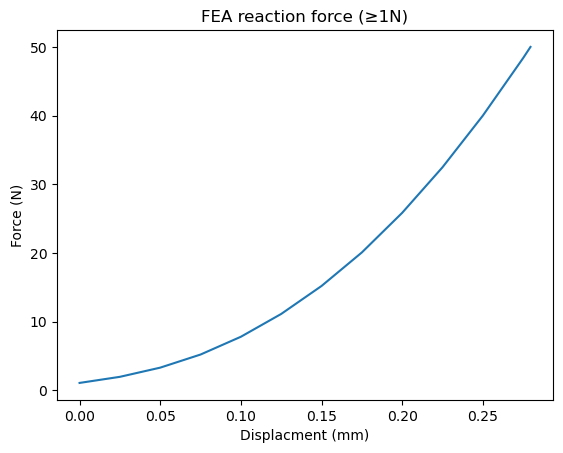

In [6]:
print(f'Total Force: {RF:.2f} N')

contact_force = 1
feaF = history_data[-history_data['value']>=contact_force]
plt.plot(feaF['time']-feaF['time'].min(), -feaF['value']) # time = displacement (time=0.8, displacement=0.8)
plt.xlabel('Displacment (mm)')
plt.ylabel('Force (N)')
plt.title('FEA reaction force (≥1N)')
#plt.savefig(
#    '/Users/matty/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/Presentations/meeting-2026-02-24/FEAForce50N.png',
#    dpi=300
#    )
plt.show()

# Tekscan results

Total Force: 50.00 N


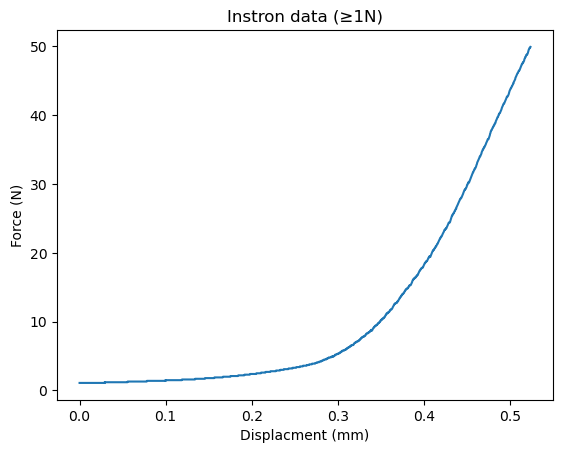

In [8]:
from phd_helpers.experiments import parse_tekscan, get_frame_at_F, get_instron_data

DIR = Path("/Users/matty/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/Experiments/TMCjoint/Testing")
#DIR = Path(r"C:\Users\scmo\OneDrive - University of Leeds\PhD-wrist\Experiments\TMCjoint\Testing")
date = "20260126"

instron_file = list(DIR.glob(f"{date}/**/0-50*.csv"))[0]
instron_data = get_instron_data(instron_file)

# upper filter to match FEA , lower filter to ensure contact between parts
instronF = instron_data[(instron_data['force']*1e3 > contact_force) & (instron_data['force']*1e3 <= RF)]

instronRF = np.max(instron_data['force']*1e3)
print(f'Total Force: {instronRF:.2f} N')

plt.plot(instronF['displacement']-instronF['displacement'].min(), instronF['force']*1e3)
plt.xlabel('Displacment (mm)')
plt.ylabel('Force (N)')
plt.title('Instron data (≥1N)')
#plt.savefig(
#    '/Users/matty/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/Presentations/meeting-2026-02-24/TekForce50N.png',
#    dpi=300
#    )
plt.show()

In [56]:
tek_files = list(DIR.glob(f"{date}/*/*.asm"))
tek_file = list(DIR.glob(f"{date}/*/0-50.asm"))[0]
header, (s1, s2, s3, s4) = parse_tekscan(tek_file)

# get frame at RF
frame = get_frame_at_F(instronRF, instron_data, header)
tek_img = s4[frame]

sensor_vals = tek_img # shape (11, 11)
sensor_vals /= 2.5 # adjust pressure values to account for bad calibration
threshold = 0.0
sensor_vals = np.where(sensor_vals <= threshold, 0, sensor_vals)

press_min = np.min( [np.min(mesh['CPRESS']), np.min(sensor_vals)] )
press_max = np.max( [np.max(mesh['CPRESS']), np.max(sensor_vals)] )
clims = (press_min, press_max)

# CONATACT PRESSURE

### FEA

In [ ]:
# create and position sensor plane relative to mesh
nc = 11 # n sensor cells
width = 13.97
height = width
centre = (5.8, 0, -2.8)

sensor = pv.Plane(
    center=centre,
    direction=(1, 0, 0),
    i_size=width, j_size=height,
    i_resolution=nc, j_resolution=nc,  # 11x11 cells
)

print(f'Total force:   {RF:.2f} N')
print(f'Peak Pressure: {np.max(cartilage_surf['CPRESS']):.2f} MPa')

pl = pv.Plotter()
pl.add_mesh(cartilage_surf, scalars='CPRESS', show_edges=False, cmap='Blues', clim=clims, show_scalar_bar=True)
pl.add_mesh(bone_shell, color='gray')
#pl.add_mesh(sensor, color="black", opacity=1.0, style='wireframe', line_width=1)
#pl.add_text('FEA', position='upper_right')
pl.camera_position = [(39.046482367234965, 0.8534680799516998, -1.6513275067270965),
 (0.0600991789958476, 0.8534680799516998, -1.6513275067270965),
 (0.0, 0.0, 1.0)]
pl.show()

Total force:   50.00 N
Peak Pressure: 2.63 MPa


Widget(value='<iframe src="http://localhost:64482/index.html?ui=P_0x16add5a60_0&reconnect=auto" class="pyvista…

pl.screenshot(
    '/Users/matty/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/Presentations/meeting-2026-02-24/FEAPress50N',
    return_img=False,
    transparent_background=True,
    scale=4
)

### TEKSCAN

In [57]:
# project sensor values onto mesh
project_sensor(cartilage_surf, sensor, sensor_vals, data_loc='cells')

print(f'Total force:   {instronRF:.2f} N')
print(f'Peak Pressure: {np.max(cartilage_surf['tek_press']):.2f} MPa')

# plot
pl = pv.Plotter()
pl.add_mesh(cartilage_surf, scalars=cartilage_surf.cell_data['tek_press'], show_edges=False, cmap='Blues', clim=clims, show_scalar_bar=True)
pl.add_mesh(bone_shell, color='gray')
pl.add_mesh(sensor, color="black", opacity=1.0, style='wireframe', line_width=1)
#pl.add_text('Tekscan', position='upper_right')
pl.camera_position = [(39.046482367234965, 0.8534680799516998, -1.6513275067270965),
 (0.0600991789958476, 0.8534680799516998, -1.6513275067270965),
 (0.0, 0.0, 1.0)]
pl.show()


Total force:   50.00 N
Peak Pressure: 2.94 MPa


Widget(value='<iframe src="http://localhost:64482/index.html?ui=P_0x338b72840_13&reconnect=auto" class="pyvist…

pl.screenshot(
    '/Users/matty/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/Presentations/meeting-2026-02-24/TekPress',
    return_img=False,
    transparent_background=True,
    scale=4
)

### FEA downscaled

In [45]:
# project sensor values onto mesh
fea_grid = project_sensor(cartilage_surf, sensor, sensor_vals, data_loc='cells', 
                            downscale_fea=True, return_fea_grid=True, downscale_mode='mean')

print(f'Total force:   {instronRF:.2f} N')
print(f'Peak Pressure: {np.max(cartilage_surf['fea_press']):.2f} MPa')

# plot
pl = pv.Plotter()
pl.add_mesh(cartilage_surf, scalars=cartilage_surf.cell_data['fea_press'], show_edges=False, cmap='Blues', clim=clims, show_scalar_bar=True)
pl.add_mesh(bone_shell, color='gray')
pl.add_mesh(sensor, color="black", opacity=1.0, style='wireframe', line_width=1)
#pl.add_text('Tekscan', position='upper_right')
pl.camera_position = [(39.046482367234965, 0.8534680799516998, -1.6513275067270965),
 (0.0600991789958476, 0.8534680799516998, -1.6513275067270965),
 (0.0, 0.0, 1.0)]
pl.show()


Total force:   50.00 N
Peak Pressure: 2.16 MPa


Widget(value='<iframe src="http://localhost:64482/index.html?ui=P_0x31a349eb0_12&reconnect=auto" class="pyvist…

### Sensor grids

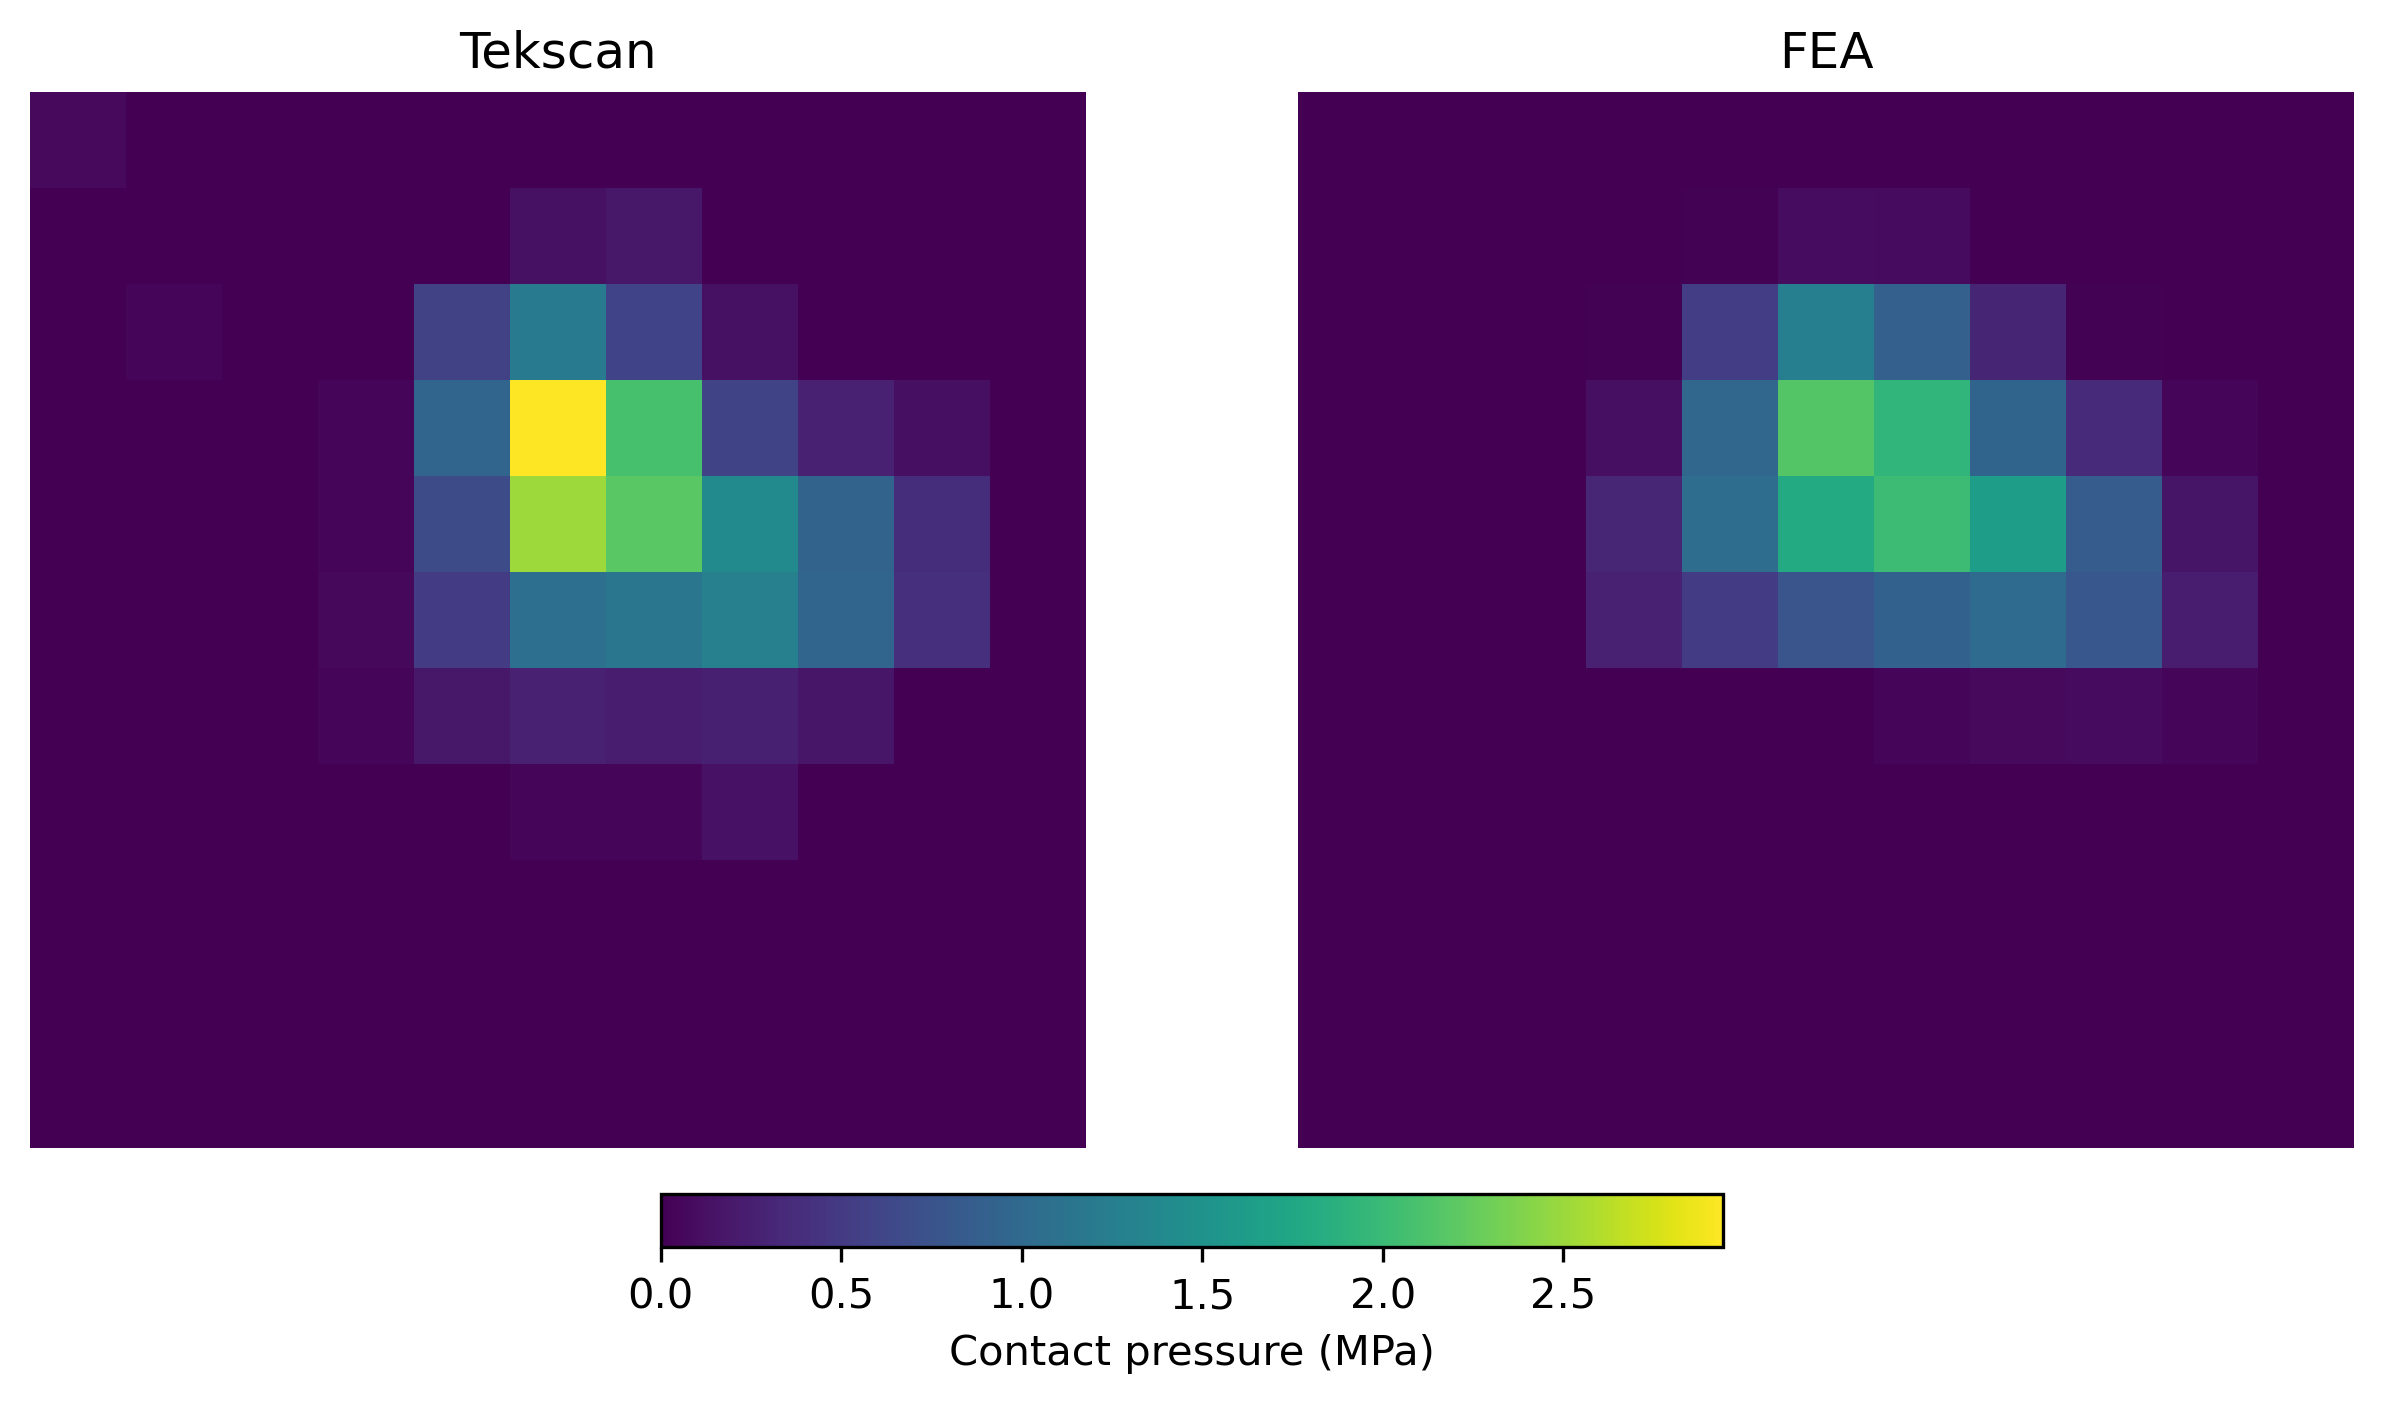

In [ ]:
fig, ax = plt.subplots(1, 2, dpi=300, figsize=(10, 5))

titles = ['Tekscan', 'FEA']
for i, grid in enumerate([sensor_vals, fea_grid]):
    im = ax[i].imshow(grid[::-1], cmap='viridis', vmin=clims[0], vmax=clims[1])
    ax[i].axis('off')

    ax[i].set_title(titles[i])

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, orientation='horizontal')
cbar.set_label('Contact pressure (MPa)')


# CARTILAGE HEIGHT CHANGE

In [10]:
max_h_ratio_id = np.argmin(mesh['cartilage_h_diff'])

print(f"Max cartilage height (undeformed): {mesh['cartilage_h'].max():.4f} mm")
print(f"  Max cartilage height (deformed): {mesh['cartilage_h_def'].max():.4f} mm")
print(f'             Max bone deformation: {bone_shell['Umag'].max():.4f} mm')

print(f"   Max change in cartilage height: {mesh['cartilage_h_ratio'].min()*100: .2f} %")

pl = pv.Plotter()
pl.add_mesh(bone_shell, color='gray', opacity=1.0)
#pl.add_mesh(mesh, scalars='cartilage_h_ratio', cmap='viridis')
pl.add_mesh(cartilage_surf, scalars='cartilage_h_ratio')
pl.add_points(mesh.points[max_h_ratio_id], point_size=20, render_points_as_spheres=True, color='white')
#pl.add_mesh(sensor, color="black", opacity=1.0, style='wireframe', line_width=1)
pl.camera_position = [(39.046482367234965, 0.8534680799516998, -1.6513275067270965),
 (0.0600991789958476, 0.8534680799516998, -1.6513275067270965),
 (0.0, 0.0, 1.0)]
pl.show()

Max cartilage height (undeformed): 0.7867 mm
  Max cartilage height (deformed): 0.8640 mm
             Max bone deformation: 0.0043 mm
   Max change in cartilage height: -43.30 %


Widget(value='<iframe src="http://localhost:52653/index.html?ui=P_0x24402705fa0_2&reconnect=auto" class="pyvis…

pl.screenshot(
    '/Users/matty/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/Presentations/meeting-2026-02-24/CartilageHeight',
    return_img=False,
    transparent_background=True,
    scale=4
)

# CONTACT AREA

In [11]:
A = mesh['CNAREA'].sum()

print(f'Contact area: {A:.2f} mm^2')

pl = pv.Plotter()
pl.add_mesh(mesh, scalars='CNAREA', cmap='Blues')
pl.camera_position = [(39.046482367234965, 0.8534680799516998, -1.6513275067270965),
 (0.0600991789958476, 0.8534680799516998, -1.6513275067270965),
 (0.0, 0.0, 1.0)]
pl.show()

Contact area: 51.30 mm^2


Widget(value='<iframe src="http://localhost:52653/index.html?ui=P_0x24402707260_3&reconnect=auto" class="pyvis…

# mesh quality change

#### BEFORE

In [178]:
qual = check_mesh_quality(mesh.extract_cells_by_type(10), 'tet')
mesh_quality_summary(qual)

radius_ratio 435/245645 cells outside of acceptable range (0.4, 1.0)
shape 19/245645 cells outside of acceptable range (0.4, 1.0)
aspect_ratio 409/245645 cells outside of acceptable range (1.0, 3.0)
scaled_jacobian 8/245645 cells outside of acceptable range (0.2, 1.0)
aspect_frobenius 386/245645 cells outside of acceptable range (1.0, 2.0)
condition 62/245645 cells outside of acceptable range (1.0, 3.0)


,mean,best,worst,acceptable_range,acceptable_range_pct,bad_cells,95%
metric,,,,,,,
min_angle,50.715365,69.742176,12.198603,"(10, 70.53)",100.000000,0,"(35.72, 69.74)"
max_angle,96.495235,71.462375,160.827357,"(70.53, 170)",100.000000,0,"(71.46, 121.92)"
radius_ratio,0.853942,0.999402,0.195476,"(0.4, 1.0)",99.822915,435,"(0.67, 1.0)"
shape,0.879830,0.999522,0.312141,"(0.4, 1.0)",99.992265,19,"(0.73, 1.0)"
aspect_ratio,1.379986,1.012780,5.365602,"(1.0, 3.0)",99.833500,409,"(1.01, 1.79)"
scaled_jacobian,0.709387,0.992582,0.096956,"(0.2, 1.0)",99.996743,8,"(0.5, 0.99)"
aspect_frobenius,1.147823,1.000478,3.203680,"(1.0, 2.0)",99.842863,386,"(1.0, 1.38)"
condition,1.160769,1.000479,4.540146,"(1.0, 3.0)",99.974760,62,"(1.0, 1.44)"
distortion,1.000000,1.000000,1.000000,"(0.5, 1.0)",100.000000,0,"(1.0, 1.0)"


#### AFTER

In [179]:
qual_def = check_mesh_quality(mesh_def.extract_cells_by_type(10), 'tet')
mesh_quality_summary(qual_def)

min_angle 66/245645 cells outside of acceptable range (10, 70.53)
max_angle 2/245645 cells outside of acceptable range (70.53, 170)
radius_ratio 5568/245645 cells outside of acceptable range (0.4, 1.0)
shape 1130/245645 cells outside of acceptable range (0.4, 1.0)
aspect_ratio 3003/245645 cells outside of acceptable range (1.0, 3.0)
scaled_jacobian 1832/245645 cells outside of acceptable range (0.2, 1.0)
aspect_frobenius 3915/245645 cells outside of acceptable range (1.0, 2.0)
condition 573/245645 cells outside of acceptable range (1.0, 3.0)


,mean,best,worst,acceptable_range,acceptable_range_pct,bad_cells,95%
metric,,,,,,,
min_angle,48.961486,69.834015,5.035128,"(10, 70.53)",99.973132,66,"(30.33, 69.83)"
max_angle,98.432908,71.478636,172.012321,"(70.53, 170)",99.999186,2,"(71.48, 127.96)"
radius_ratio,0.822986,0.999400,0.020267,"(0.4, 1.0)",97.733314,5568,"(0.53, 1.0)"
shape,0.856430,0.999520,0.184584,"(0.4, 1.0)",99.539987,1130,"(0.63, 1.0)"
aspect_ratio,1.458467,1.012776,13.087119,"(1.0, 3.0)",98.777504,3003,"(1.01, 2.15)"
scaled_jacobian,0.676384,0.992559,0.049394,"(0.2, 1.0)",99.254208,1832,"(0.4, 0.99)"
aspect_frobenius,1.194649,1.000480,5.417574,"(1.0, 2.0)",98.406237,3915,"(1.0, 1.59)"
condition,1.210547,1.000481,9.538413,"(1.0, 3.0)",99.766737,573,"(1.0, 1.68)"
distortion,1.000000,1.000000,1.000000,"(0.5, 1.0)",100.000000,0,"(1.0, 1.0)"


In [182]:
plot_bad_cells2(mesh, qual,'min_angle', (0, 20))

min_angle
Bad cells =  348


Widget(value='<iframe src="http://localhost:54898/index.html?ui=P_0x191bfb208f0_68&reconnect=auto" class="pyvi…

In [183]:
plot_bad_cells2(mesh_def, qual_def,'min_angle', (0, 20))

min_angle
Bad cells =  1815


Widget(value='<iframe src="http://localhost:54898/index.html?ui=P_0x191bfb22300_69&reconnect=auto" class="pyvi…